In [1]:
#Importing Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
#Loading and exploring Dataset
train_dir = "/kaggle/input/datasets/tanvirmahtabtaneem/brain-tumor-mri-dataset-for-custom-cnn-training/Training"
test_dir = "/kaggle/input/datasets/tanvirmahtabtaneem/brain-tumor-mri-dataset-for-custom-cnn-training/Testing"

classes = ['glioma','meningioma','notumor','pituitary']

In [3]:
# Training transformations (better image quality + augmentation)
train_transform = transforms.Compose([
    transforms.Resize(256),              # preserve aspect ratio
    transforms.CenterCrop(224),          # focus on center region
    transforms.RandomHorizontalFlip(),   # augmentation
    transforms.RandomRotation(10),       # augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Testing transformations (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Load dataset
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

# DataLoader (batch size = 32 → balance between speed & memory)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 5600
Test size: 1600


In [4]:
#Model 1: WITH BatchNorm + Dropout
class BrainTumorCNN(nn.Module):
    
    def __init__(self):
        super(BrainTumorCNN,self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),     # improves training stability
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,256),
            nn.ReLU(),
            nn.Dropout(0.5),        # prevents overfitting
            nn.Linear(256,4)
        )
        
    def forward(self,x):
        x=self.conv(x)
        x=self.fc(x)
        return x

In [5]:
#Model 2: WITHOUT BatchNorm + Dropout
class BrainTumorCNN_NoReg(nn.Module):
    
    def __init__(self):
        super(BrainTumorCNN_NoReg,self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,256),
            nn.ReLU(),
            nn.Linear(256,4)
        )
        
    def forward(self,x):
        x=self.conv(x)
        x=self.fc(x)
        return x

In [ ]:
#Model Summary for model with regularization
model = BrainTumorCNN().to(device)
print(model)

BrainTumorCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.

In [ ]:
#Model Summary for model without regularization
model = BrainTumorCNN_NoReg().to(device)
print(model)

BrainTumorCNN_NoReg(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [8]:
#Training Setup
learning_rate = 0.001    
epochs = 20               
criterion = nn.CrossEntropyLoss()

def train_model(model):
    
    model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler → reduces LR over time
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    train_losses = []
    train_acc = []
    
    for epoch in range(epochs):
        
        model.train()
        
        running_loss = 0
        correct = 0
        total = 0
        
        for images,labels in train_loader:
            
            images,labels = images.to(device),labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs,labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _,pred = torch.max(outputs,1)
            total += labels.size(0)
            correct += (pred==labels).sum().item()
        
        scheduler.step()
        
        epoch_loss = running_loss/len(train_loader)
        epoch_acc = 100*correct/total
        
        train_losses.append(epoch_loss)
        train_acc.append(epoch_acc)
        
        print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.2f}%")
    
    return model, train_losses, train_acc

Learning Rate (0.001):
A learning rate of 0.001 was selected because it provides stable and efficient convergence when using the Adam optimizer. A higher value may cause unstable training, while a lower value would slow down learning.

Batch Size (32):
Batch size 32 was chosen as a balance between computational efficiency and memory usage. It allows faster training while maintaining stable gradient updates.

Number of Epochs (20):
The model was trained for 20 epochs to allow sufficient learning and better convergence. This helps the model capture more complex patterns compared to fewer epochs, while still controlling overfitting using regularization techniques.

Optimizer (Adam):
Adam optimizer was used because it adapts the learning rate automatically for each parameter, leading to faster convergence compared to traditional optimizers like SGD.

Learning Rate Scheduler (StepLR):
StepLR reduces the learning rate after a fixed number of epochs (step size = 5, gamma = 0.5). This helps the model fine-tune its weights and improves final performance.

Dropout (0.5):
Dropout was used to prevent overfitting by randomly disabling neurons during training, forcing the model to learn more robust features.

Batch Normalization:
Batch normalization was applied to stabilize and accelerate training by normalizing feature distributions, leading to better performance and faster convergence.

In [9]:
#Training Both Models
print("Training WITH BatchNorm & Dropout")
model1 = BrainTumorCNN()
model1, loss1, acc1 = train_model(model1)

print("\nTraining WITHOUT BatchNorm & Dropout")
model2 = BrainTumorCNN_NoReg()
model2, loss2, acc2 = train_model(model2)

Training WITH BatchNorm & Dropout
Epoch 1: Loss=2.9104, Acc=54.62%
Epoch 2: Loss=0.8139, Acc=63.45%
Epoch 3: Loss=0.7498, Acc=66.79%
Epoch 4: Loss=0.7619, Acc=64.55%
Epoch 5: Loss=0.7621, Acc=65.46%
Epoch 6: Loss=0.6544, Acc=70.25%
Epoch 7: Loss=0.6030, Acc=72.50%
Epoch 8: Loss=0.5891, Acc=74.46%
Epoch 9: Loss=0.5656, Acc=73.39%
Epoch 10: Loss=0.5540, Acc=74.59%
Epoch 11: Loss=0.5219, Acc=75.75%
Epoch 12: Loss=0.4996, Acc=76.91%
Epoch 13: Loss=0.4891, Acc=76.64%
Epoch 14: Loss=0.4767, Acc=77.30%
Epoch 15: Loss=0.4593, Acc=78.55%
Epoch 16: Loss=0.4465, Acc=78.82%
Epoch 17: Loss=0.4454, Acc=78.61%
Epoch 18: Loss=0.4252, Acc=80.14%
Epoch 19: Loss=0.4151, Acc=80.73%
Epoch 20: Loss=0.4296, Acc=80.59%

Training WITHOUT BatchNorm & Dropout
Epoch 1: Loss=0.7261, Acc=73.98%
Epoch 2: Loss=0.3750, Acc=85.70%
Epoch 3: Loss=0.2510, Acc=90.68%
Epoch 4: Loss=0.1616, Acc=94.18%
Epoch 5: Loss=0.1301, Acc=95.55%
Epoch 6: Loss=0.0674, Acc=97.71%
Epoch 7: Loss=0.0468, Acc=98.48%
Epoch 8: Loss=0.0311, Acc=

In [10]:
#Evaluation Function
def evaluate(model):
    
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images,labels in test_loader:
            
            images,labels = images.to(device),labels.to(device)
            
            outputs = model(images)
            _,pred = torch.max(outputs,1)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

In [11]:
#Evaluating Both Models
labels1, preds1 = evaluate(model1)
labels2, preds2 = evaluate(model2)

print("Model WITH BN & Dropout")
print(classification_report(labels1, preds1, target_names=classes))

print("\nModel WITHOUT BN & Dropout")
print(classification_report(labels2, preds2, target_names=classes))

Model WITH BN & Dropout
              precision    recall  f1-score   support

      glioma       0.93      0.69      0.79       400
  meningioma       0.80      0.67      0.73       400
     notumor       0.72      0.99      0.83       400
   pituitary       0.93      0.97      0.95       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600


Model WITHOUT BN & Dropout
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.90      0.94      0.92       400
     notumor       0.90      0.99      0.94       400
   pituitary       0.97      1.00      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



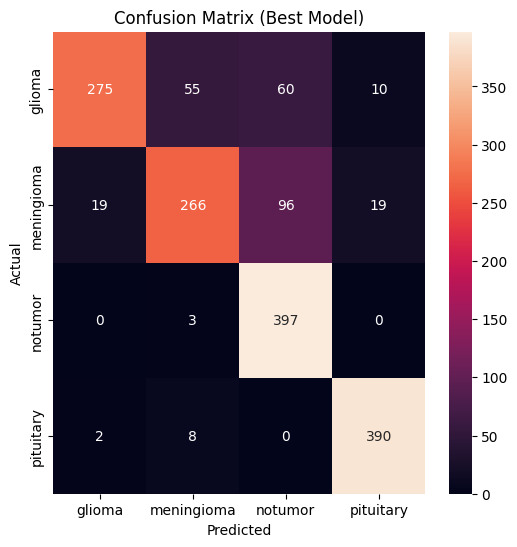

In [12]:
#Confusion Matrix
cm = confusion_matrix(labels1, preds1)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

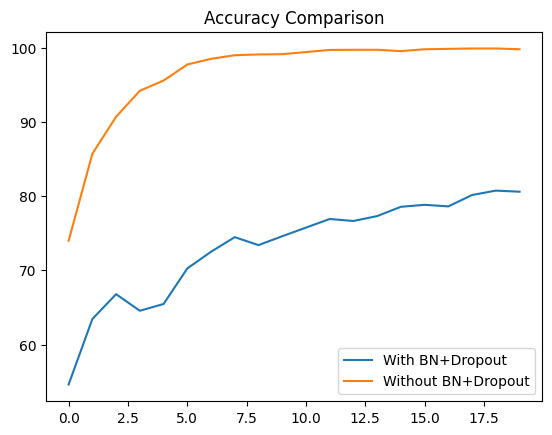

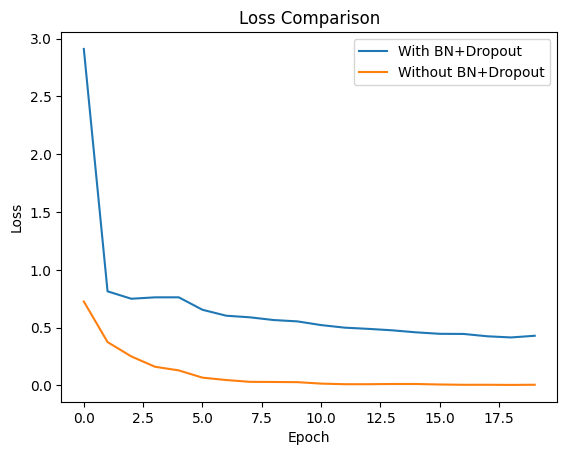

In [13]:
# Accuracy
plt.plot(acc1, label="With BN+Dropout")
plt.plot(acc2, label="Without BN+Dropout")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

# Loss
plt.plot(loss1, label="With BN+Dropout")
plt.plot(loss2, label="Without BN+Dropout")
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
#Saved Model
torch.save(model1.state_dict(), "brain_tumor_model.pth")